In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Part 1: Prepare the Data

In [2]:

df = pd.read_csv('myopia.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (618, 15)


,AGE,SPHEQ,AL,ACD,LT,VCD,SPORTHR,READHR,COMPHR,STUDYHR,TVHR,DIOPTERHR,MOMMY,DADMY,MYOPIC
0,6,-0.052,21.889999,3.690,3.498,14.70,45,8,0,0,10,34,1,1,1
1,6,0.608,22.379999,3.702,3.392,15.29,4,0,1,1,7,12,1,1,0
2,6,1.179,22.490000,3.462,3.514,15.52,14,0,2,0,10,14,0,0,0
3,6,0.525,22.200001,3.862,3.612,14.73,18,11,0,0,4,37,0,1,1
4,5,0.697,23.290001,3.676,3.454,16.16,14,0,0,0,4,4,1,0,0


In [3]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 618 entries, 0 to 617
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AGE        618 non-null    int64  
 1   SPHEQ      618 non-null    float64
 2   AL         618 non-null    float64
 3   ACD        618 non-null    float64
 4   LT         618 non-null    float64
 5   VCD        618 non-null    float64
 6   SPORTHR    618 non-null    int64  
 7   READHR     618 non-null    int64  
 8   COMPHR     618 non-null    int64  
 9   STUDYHR    618 non-null    int64  
 10  TVHR       618 non-null    int64  
 11  DIOPTERHR  618 non-null    int64  
 12  MOMMY      618 non-null    int64  
 13  DADMY      618 non-null    int64  
 14  MYOPIC     618 non-null    int64  
dtypes: float64(5), int64(10)
memory usage: 72.6 KB


In [4]:
df.describe()

,AGE,SPHEQ,AL,ACD,LT,VCD,SPORTHR,READHR,COMPHR,STUDYHR,TVHR,DIOPTERHR,MOMMY,DADMY,MYOPIC
count,618.000000,618.000000,618.000000,618.000000,618.000000,618.000000,618.000000,618.000000,618.000000,618.000000,618.000000,618.000000,618.000000,618.000000,618.000000
mean,6.299353,0.801010,22.496780,3.578629,3.541453,15.376780,11.953074,2.796117,2.105178,1.490291,8.948220,26.017799,0.506472,0.498382,0.131068
std,0.712950,0.625918,0.680141,0.230394,0.154519,0.664183,7.968296,3.068191,3.056508,2.216207,5.719021,16.031715,0.500363,0.500402,0.337748
min,5.000000,-0.699000,19.900000,2.772000,2.960000,13.380000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,6.000000,0.456250,22.040001,3.424000,3.436000,14.930000,6.000000,0.000000,0.000000,0.000000,4.250000,15.000000,0.000000,0.000000,0.000000
50%,6.000000,0.729000,22.464999,3.585000,3.542000,15.360000,10.000000,2.000000,1.000000,1.000000,8.000000,23.000000,1.000000,0.000000,0.000000
75%,6.000000,1.034000,22.969999,3.730000,3.640000,15.840000,16.000000,4.000000,3.000000,2.000000,12.000000,34.000000,1.000000,1.000000,0.000000
max,9.000000,4.372000,24.559999,4.250000,4.112000,17.299999,45.000000,20.000000,30.000000,15.000000,31.000000,101.000000,1.000000,1.000000,1.000000


In [5]:

df_ml = df.drop(columns=['MYOPIC'])
print(f'Features after dropping MYOPIC: {df_ml.shape[1]}')
print(f'Columns: {list(df_ml.columns)}')

Features after dropping MYOPIC: 14
Columns: ['AGE', 'SPHEQ', 'AL', 'ACD', 'LT', 'VCD', 'SPORTHR', 'READHR', 'COMPHR', 'STUDYHR', 'TVHR', 'DIOPTERHR', 'MOMMY', 'DADMY']


In [6]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml)

print(f'Mean after scaling : {X_scaled.mean():.6f}  (≈ 0)')
print(f'Std  after scaling : {X_scaled.std():.6f}  (≈ 1)')

Mean after scaling : 0.000000  (≈ 0)
Std  after scaling : 1.000000  (≈ 1)


---
## Part 2: Apply Dimensionality Reduction
### 2a — PCA

In [7]:
# Preserve 90% of explained variance
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Original features  : {df_ml.shape[1]}')
print(f'PCA components     : {X_pca.shape[1]}  (preserving 90% variance)')
print(f'Explained variance : {np.round(pca.explained_variance_ratio_, 3)}')
print(f'Total variance kept: {pca.explained_variance_ratio_.sum()*100:.1f}%')

Original features  : 14
PCA components     : 10  (preserving 90% variance)
Explained variance : [0.212 0.157 0.087 0.083 0.076 0.07  0.065 0.064 0.054 0.052]
Total variance kept: 91.9%


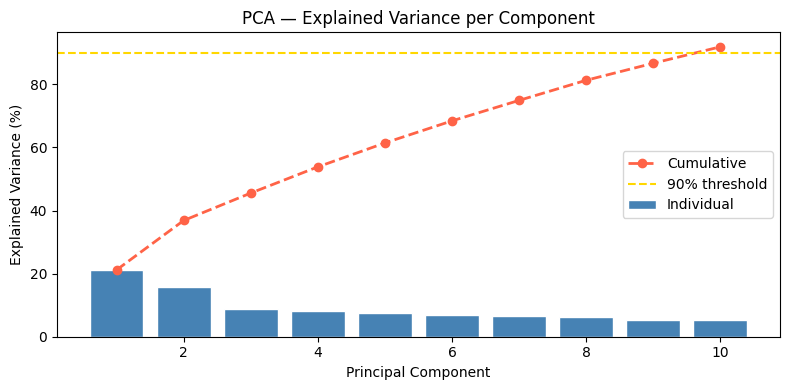


→ PCA reduced the dataset from 14 features to 10 components.


In [8]:

fig, ax = plt.subplots(figsize=(8, 4))
components = range(1, X_pca.shape[1] + 1)

ax.bar(components, pca.explained_variance_ratio_ * 100,
       color='steelblue', edgecolor='white', label='Individual')
ax.plot(components, np.cumsum(pca.explained_variance_ratio_) * 100,
        'o--', color='tomato', linewidth=2, markersize=6, label='Cumulative')
ax.axhline(90, color='gold', linestyle='--', linewidth=1.5, label='90% threshold')

ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA — Explained Variance per Component')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n→ PCA reduced the dataset from {df_ml.shape[1]} features to {X_pca.shape[1]} components.')

### 2b — t-SNE

In [9]:

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)
print(f't-SNE output shape: {X_tsne.shape}')

t-SNE output shape: (618, 2)


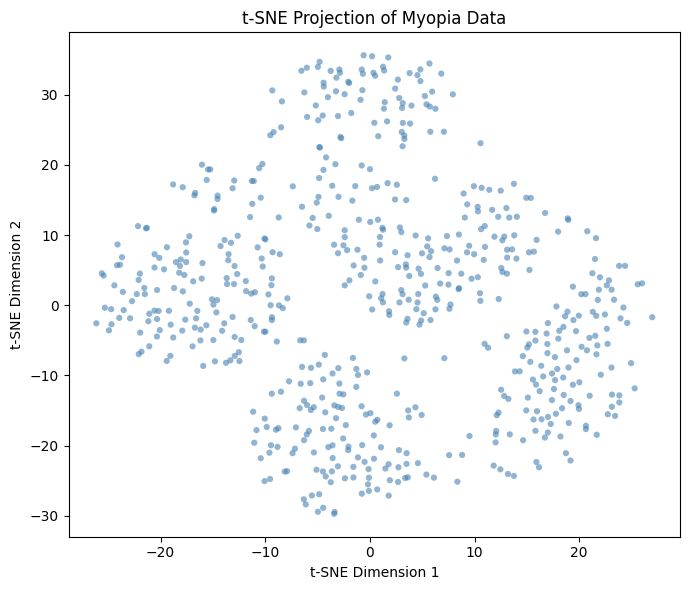

→ The t-SNE plot shows some loose groupings, suggesting natural clusters exist in the data.


In [10]:

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
           c='steelblue', alpha=0.6, s=20, edgecolors='none')

ax.set_title('t-SNE Projection of Myopia Data')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.show()

print('→ The t-SNE plot shows some loose groupings, suggesting natural clusters exist in the data.')

---
## Part 3: Perform a Cluster Analysis with K-Means

In [11]:
# Elbow method — inertia for k = 1 to 10
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    print(f'  k={k:2d}  |  inertia = {km.inertia_:.2f}')

  k= 1  |  inertia = 7948.91
  k= 2  |  inertia = 6794.42
  k= 3  |  inertia = 6030.39
  k= 4  |  inertia = 5662.80
  k= 5  |  inertia = 5381.41
  k= 6  |  inertia = 5148.24
  k= 7  |  inertia = 4938.76
  k= 8  |  inertia = 4753.65
  k= 9  |  inertia = 4581.14
  k=10  |  inertia = 4473.40


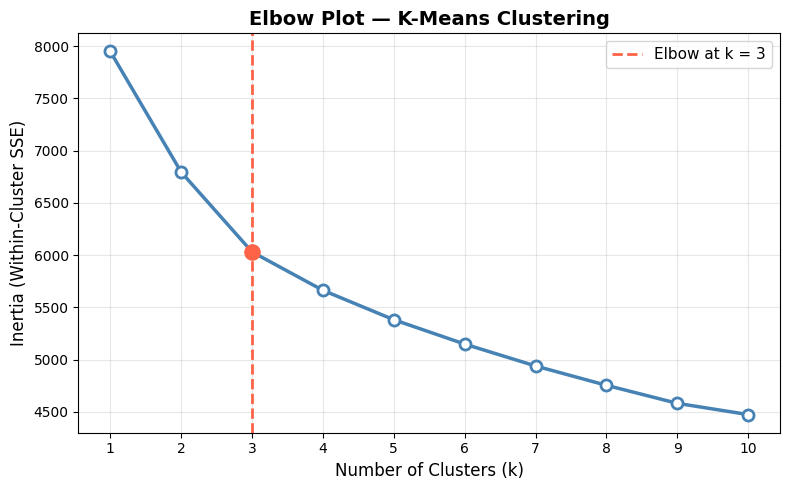

→ The elbow appears at k = 3


In [12]:
# Plot the elbow curve
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(list(k_range), inertias, 'o-', color='steelblue',
        linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)

# Detect elbow automatically
deltas = np.diff(inertias)
delta2 = np.diff(deltas)
best_k = int(np.argmax(delta2) + 2)

ax.axvline(best_k, color='tomato', linestyle='--', linewidth=2,
           label=f'Elbow at k = {best_k}')
ax.scatter([best_k], [inertias[best_k - 1]], color='tomato', s=120, zorder=5)

ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (Within-Cluster SSE)', fontsize=12)
ax.set_title('Elbow Plot — K-Means Clustering', fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'→ The elbow appears at k = {best_k}')

In [13]:
# Final K-Means with best k
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = km_final.fit_predict(X_pca)

# Count patients per cluster
unique, counts = np.unique(labels, return_counts=True)
for cl, cnt in zip(unique, counts):
    print(f'  Cluster {cl + 1}: {cnt} patients')

  Cluster 1: 239 patients
  Cluster 2: 266 patients
  Cluster 3: 113 patients


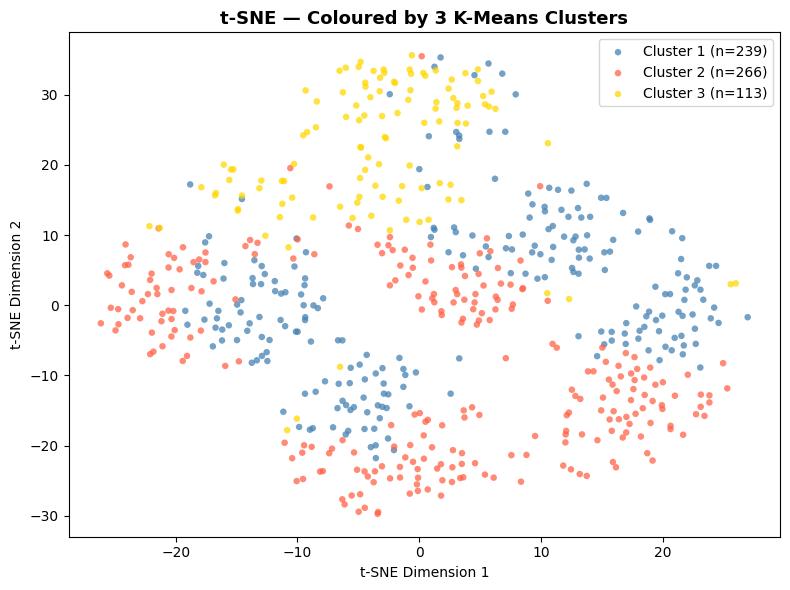

In [14]:
# Visualise clusters on t-SNE plot
palette = ['steelblue', 'tomato', 'gold', 'mediumseagreen', 'orchid']

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(best_k):
    mask = labels == i
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=palette[i], alpha=0.75, s=22,
               edgecolors='none', label=f'Cluster {i + 1} (n={mask.sum()})')

ax.set_title(f't-SNE — Coloured by {best_k} K-Means Clusters', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Part 4: Recommendation

> **Yes the myopia patients can be clustered into 3 distinct groups.**  
> The elbow plot shows a clear inflection point at **k = 3**, and the t-SNE visualisation confirms that these three clusters correspond to meaningful separable patient groupings — likely representing low-risk, moderate-risk, and high-risk myopia profiles — which could guide targeted clinical interventions.